# Sentiment Analysis Using VADER

## Importing Libraries and Initial Data Loading

In [1]:
import re
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt

#Download VADER lexicon 
nltk.download('vader_lexicon')

#Download NLTK

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/selmaschouw/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [2]:
#Define path to the dataset and load it
data_path = '../data/spotify_reviews.csv'
data = pd.read_csv(data_path)

## Preprocessing

In [3]:
# Function to clean text
def clean_text(text):
    if pd.isnull(text):
        return ""
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Remove unwanted punctuation and symbols but keep exclamation marks and emojis
    text = re.sub(r'[^A-Za-z0-9\s!.,:;?@#&*()_+=\-\[\]{}<>]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    # Tokenization
    tokens = text.split()
    # Stop word removal
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word.lower() not in stop_words]
    # Stemming
    stemmer = PorterStemmer()
    tokens = [stemmer.stem(word) for word in tokens]
    return ' '.join(tokens)

data['cleaned_content'] = data['content'].apply(clean_text)

## Model Implementation 

In [4]:
# Initialize VADER sentiment analyzer
sia = SentimentIntensityAnalyzer()

# Calculate sentiment scores
data['compound'] = data['cleaned_content'].apply(lambda x: sia.polarity_scores(x)['compound'])
data['negative'] = data['cleaned_content'].apply(lambda x: sia.polarity_scores(x)['neg'])
data['neutral'] = data['cleaned_content'].apply(lambda x: sia.polarity_scores(x)['neu'])
data['positive'] = data['cleaned_content'].apply(lambda x: sia.polarity_scores(x)['pos'])

# Verify that the scores sum to 1 for individual reviews
data['Sum'] = data['negative'] + data['neutral'] + data['positive']
print(data[['cleaned_content', 'negative', 'neutral', 'positive', 'Sum']].head(10))

# Extract the year from 'at' column
data['Year'] = pd.to_datetime(data['at']).dt.year

# Ensure that the columns for grouping are numeric
numeric_columns = ['compound', 'positive', 'negative', 'neutral']

# Group by 'Year' and calculate mean sentiment scores
sentiment_by_year = data.groupby('Year')[numeric_columns].mean().reset_index()

# Verify that the proportions sum to 1 when averaged
sentiment_by_year['Sum'] = sentiment_by_year['positive'] + sentiment_by_year['negative'] + sentiment_by_year['neutral']
print(sentiment_by_year)


                                     cleaned_content  negative  neutral  \
0                                               good     0.000    0.000   
1  love app much, ive use spotifi 2 years, differ...     0.145    0.681   
2                                            perfect     0.000    0.000   
3  best around music stream app used, famili plan...     0.000    0.449   
4               yall fr gatekeep play button songs!?     0.000    0.650   
5                                               love     0.000    0.000   
6          app good start ask premium.....it control     0.000    0.633   
7                                          excel app     0.000    0.250   
8                                       like spotifi     0.000    0.286   
9                                           eat rich     0.000    0.217   

   positive  Sum  
0     1.000  1.0  
1     0.174  1.0  
2     1.000  1.0  
3     0.551  1.0  
4     0.350  1.0  
5     1.000  1.0  
6     0.367  1.0  
7     0.750  1.0  
8  

### Visualizations

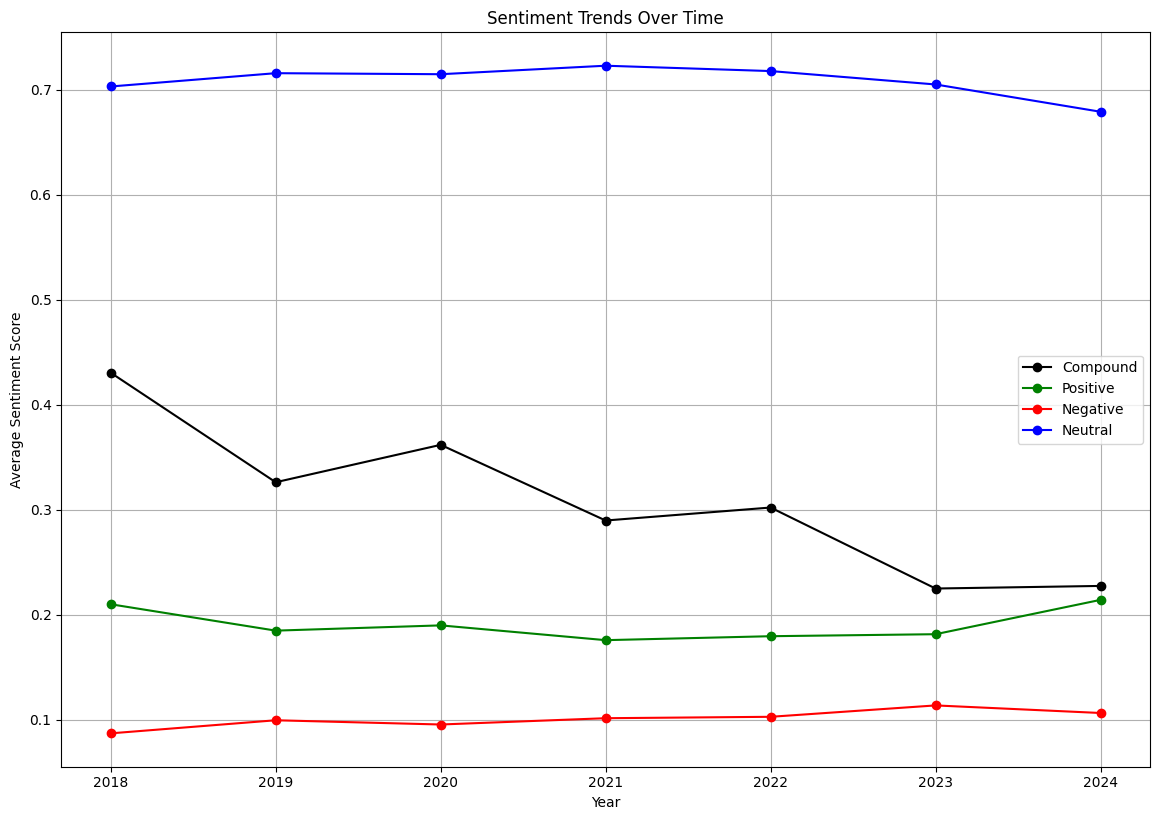

In [5]:
# Plot the figure
plt.figure(figsize=(11.7, 8.3))
plt.plot(sentiment_by_year['Year'], sentiment_by_year['compound'], label='Compound', marker='o', color='black')
plt.plot(sentiment_by_year['Year'], sentiment_by_year['positive'], label='Positive', marker='o', color='green')
plt.plot(sentiment_by_year['Year'], sentiment_by_year['negative'], label='Negative', marker='o', color='red')
plt.plot(sentiment_by_year['Year'], sentiment_by_year['neutral'], label='Neutral', marker='o', color='blue')

plt.xlabel('Year')
plt.ylabel('Average Sentiment Score')
plt.title('Sentiment Trends Over Time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

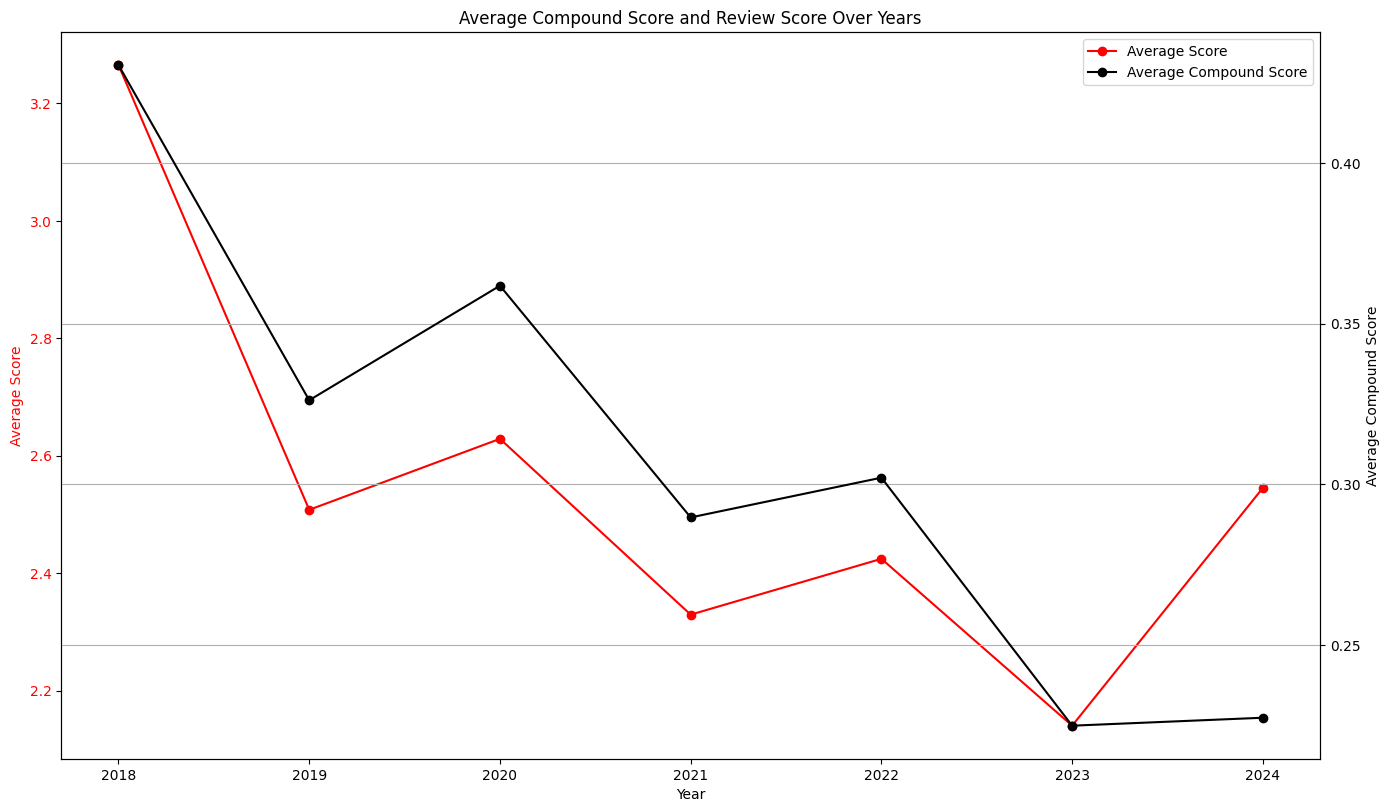

In [8]:
fig, ax1 = plt.subplots(figsize=(14, 8))

# Plot the average review scores
ax1.plot(data.groupby('Year')['score'].mean(), marker='o', label='Average Score', color='red')
ax1.set_xlabel('Year')
ax1.set_ylabel('Average Score', color='red')
ax1.tick_params(axis='y', labelcolor='red')

# Create a secondary y-axis for the compound scores
ax2 = ax1.twinx()
ax2.plot(sentiment_by_year['Year'], sentiment_by_year['compound'], marker='o', label='Average Compound Score', color='black')
ax2.set_ylabel('Average Compound Score', color='black')
ax2.tick_params(axis='y', labelcolor='black')

# Title and legend
fig.tight_layout()
plt.title('Average Compound Score and Review Score Over Years')
fig.legend(loc="upper right", bbox_to_anchor=(1,1), bbox_transform=ax1.transAxes)

# Show the plot
plt.grid(True)
plt.show()